# Module Assignment — Exploratory Data Analysis on Hotel Bookings

## Case Study: Hotel Bookings

In this assignment you'll apply everything from this module to a **large, genuinely messy** real-world dataset: **119,390 hotel bookings with 32 columns**.

You will practise the full EDA workflow:

1. **Exploring / diagnosing** the data
2. **Cleaning** — missing values, duplicates, wrong data types, invalid values
3. **Visualizing** with matplotlib
4. **Manipulating** — sorting, filtering, new columns, `groupby`, `pivot_table`, `crosstab`
5. **Drawing conclusions**

**This dataset is deliberately challenging** — it has 4 columns with missing data (one is ~94% empty!), ~32,000 duplicate rows, dates stored as text, and some physically impossible values. Read each prompt carefully and think about *why* a step is needed, not just *how*.

### Instructions

- Write your **full code** in the empty cell below each exercise
- Some exercises ask a question in **markdown** — answer it in a comment or a short written note.
- Work through the notebook **in order**: later sections rely on the cleaned DataFrame from earlier ones.
- Worked answers are in **`Module_Assignment_Hotel_Bookings_Solutions.ipynb`** — try hard before peeking.

### Key columns

| Column | Meaning |
|---|---|
| `hotel` | Resort Hotel or City Hotel |
| `is_canceled` | 1 = booking was cancelled, 0 = not |
| `lead_time` | Days between booking and arrival |
| `arrival_date_month` | Month of arrival (text, e.g. "July") |
| `adults` / `children` / `babies` | Number of guests of each type |
| `meal`, `country`, `market_segment`, `customer_type` | Categorical descriptors |
| `adr` | Average Daily Rate (price per night) |
| `agent` / `company` | IDs of the booking agent / company (lots of missing) |
| `reservation_status_date` | Date of the last status change (text) |

## Import Libraries

**Exercise 0.** Import the required libraries.

In [7]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
print(np.__version__)
print(pd.__version__)
print(matplotlib.__version__)



2.5.2
3.0.5
3.11.1


## Load Dataset

**Exercise 1.** Read `hotel_bookings.csv` into a DataFrame called `df` and display the first 5 rows.

In [8]:
# Your code here
df =  pd.read_csv("../hotel-bookings-eda/hotel_bookings.csv")
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# 1. Exploring / Diagnosing the Data

**Exercise 2.** Report the dataset's **shape** (rows, columns). Then  inspect column names, non-null counts, and dtypes.

In [96]:
# Your code here
df.shape


(119390, 32)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

**Exercise 3.** Show the summary statistics for the **numeric** columns `. Look at the `adr` column — what is suspicious about its **minimum** value?

In [9]:
# Your code here
df.describe()
#There is a data issue because it cannot be in negative

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


**Exercise 4.** Build a table showing, **for every column**, the number of missing values **and** the percentage missing — sorted from most to least missing. Which columns are the worst?

In [10]:
# Your code here
missing_values = df.isnull().sum()
missing_values
total_row = df.shape[0]

percantage_missing = (missing_values/total_row)*100
percantage_missing.sort_values()

# "company" is one of the worst (very high missing % by 94.3%).

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
babies                             0.000000
meal                               0.000000
distribution_channel               0.000000
market_segment                     0.000000
previous_cancellations             0.000000
is_repeated_guest                  0.000000
reservation_status                 0.000000
customer_type                      0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

**Exercise 5.** For the categorical columns `hotel`, `meal`, `customer_type` and `market_segment`, print the **count of each unique value**.

In [98]:
# Your code here
Hotel = df["hotel"].value_counts()
Meal = df["meal"].value_counts()
Customer_Type = df["customer_type"].value_counts()
Market_Segment = df["market_segment"].value_counts()

print("Hotel : ")
print(Hotel)
print("\nMeal : ")
print(Meal)
print("\nCustomer_Type : ")
print(Customer_Type)
print("\nMarket_Segment : ")
print(Market_Segment)


Hotel : 
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

Meal : 
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64

Customer_Type : 
customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

Market_Segment : 
market_segment
Online TA        56477
Offline TA/TO    24219
Groups           19811
Direct           12606
Corporate         5295
Complementary      743
Aviation           237
Undefined            2
Name: count, dtype: int64


# 2. Cleaning the Data

Work on a copy so the raw data stays intact: start this section with `df_clean = df.copy()`.

**Exercise 6.** Make a copy called `df_clean`. Then handle the missing values:

- `children` → fill missing with `0`
- `country` → fill missing with `"Unknown"`
- `company` and `agent` are mostly empty → **drop both columns**

Confirm there are no missing values left.

In [11]:
df_clean = df.copy()

df_clean["children"] = df_clean["children"].fillna(0)
df_clean["country"] = df_clean["country"].fillna("Unknown")
df_clean.drop(columns=["company", "agent"], inplace=True)
df_clean.isnull().sum()


hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

**Exercise 7.** How many **fully duplicated rows** does `df_clean` contain? Remove them, then confirm the count is now 0 and report the new shape.

In [16]:
fully_duplicated = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
fully_duplicated , df_clean.shape


(np.int64(32020), (87370, 30))

**Exercise 8.** Fix the data types:

- Convert `reservation_status_date` from text to a real **datetime**.
- `children` was a float because of the missing values — now convert it to **int**.

Verify with `.dtypes`.

In [100]:
# Your code here
import pandas as pd
df_clean["reservation_status_date"] = pd.to_datetime(df_clean["reservation_status_date"])
df_clean["children"] = df_clean["children"].astype(int)

df_clean.dtypes

hotel                                        str
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                           str
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                   int64
babies                                     int64
meal                                         str
country                                      str
market_segment                               str
distribution_channel                         str
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                           str
assigned_room_type  

**Exercise 9.** Remove **invalid values**:

- The `adr` (price) cannot be negative — keep only rows where `adr >= 0`.
- A booking with **zero guests** makes no sense. Create a `total_guests = adults + children + babies` column, then drop rows where `total_guests == 0`.

Report how many rows remain.

In [101]:
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

df_clean = df_clean[(df_clean["adr"] >= 0) & (df_clean["total_guests"] > 0)]

df_clean.shape

(119209, 31)

# 3. Visualizing the Data 

**Exercise 10.** Plot a **histogram** of `lead_time` (use `bins=50`). Add a title and axis labels. What does the shape tell you about how far in advance people book?

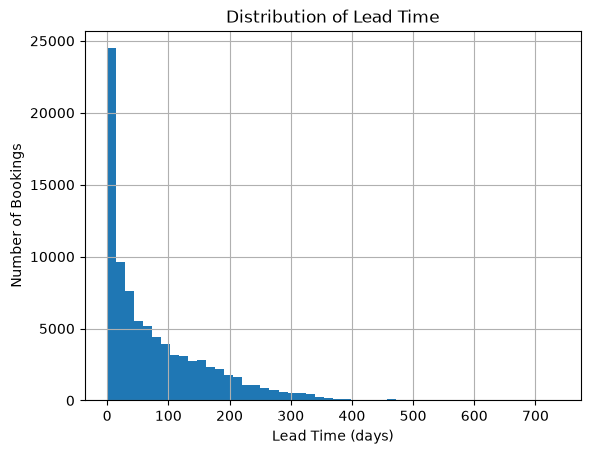

In [20]:
import matplotlib.pyplot as plt

df_clean["lead_time"].hist(bins= 50)
plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()

**Exercise 11.** Make a **bar chart** of the number of bookings per `hotel` (Resort vs City). Use `value_counts()` and label the chart.

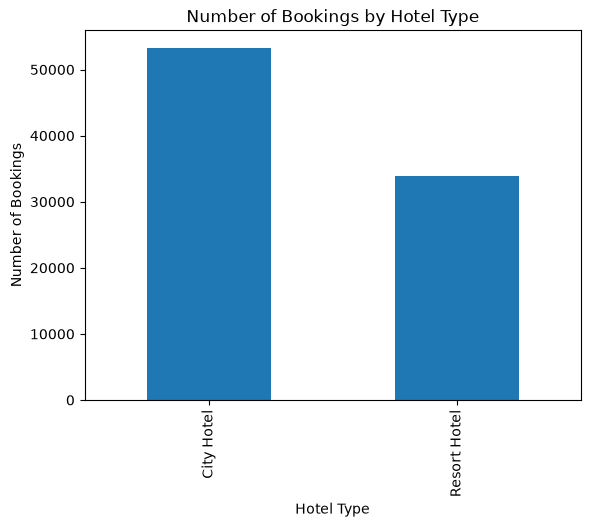

In [45]:
nb_booking_per_hotel = df_clean["hotel"].value_counts()
nb_booking_per_hotel.plot(x = "Resort " , y = "City" , kind="bar")
plt.title("Number of Bookings by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.show()


**Exercise 12.** Draw a **scatter plot** of `lead_time` (x) vs `adr` (y). Use `alpha` and a small marker size `s` so the dense cloud is readable.

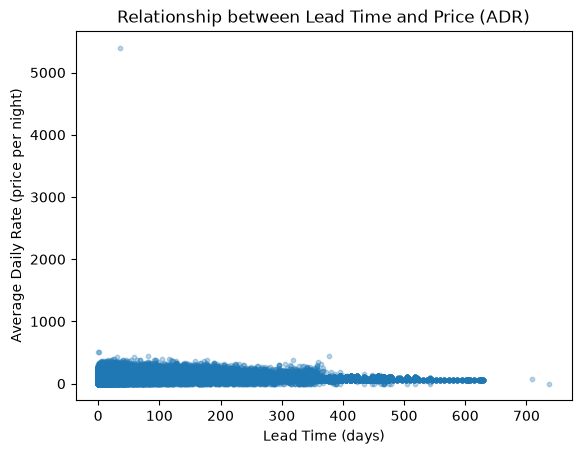

In [102]:

plt.scatter(x =df_clean["lead_time"], y =df_clean["adr"], alpha=0.3, s=10)
plt.title("Relationship between Lead Time and Price (ADR)")
plt.xlabel("Lead Time (days)")
plt.ylabel("Average Daily Rate (price per night)")
plt.show()

**Exercise 13.** Build a **2×2 grid of subplots** (`figsize=(12, 9)`):

- histogram of `adr`
- histogram of `total_guests`
- bar chart of `customer_type` counts
- bar chart of `is_canceled` counts (0 vs 1)

Give each subplot a title and call `fig.tight_layout()`.

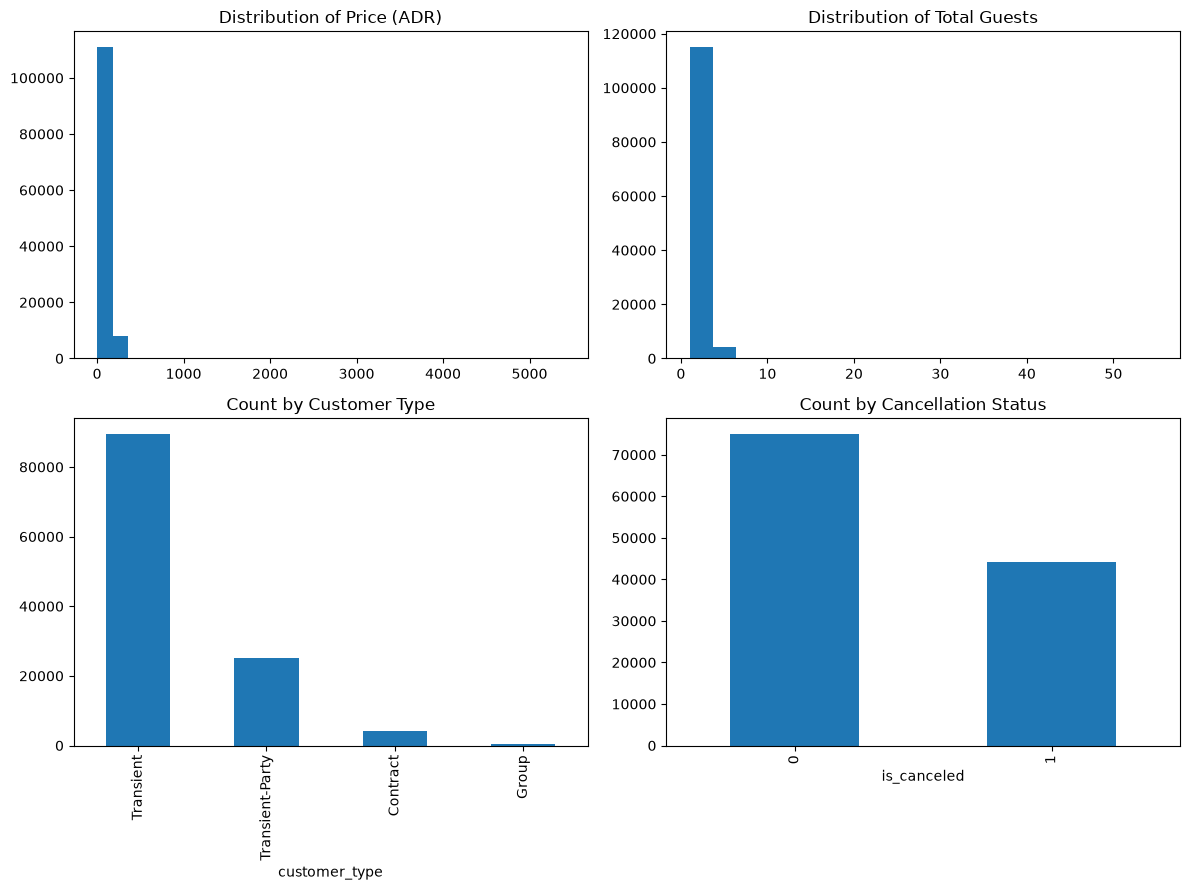

In [103]:

fig , ((ax1 ,ax2) , (ax3 , ax4)) = plt.subplots(nrows= 2 , ncols=2 , figsize = (12,9))

ax1.hist(df_clean["adr"], bins=30)
ax1.set_title("Distribution of Price (ADR)")

ax2.hist(df_clean["total_guests"], bins=20)
ax2.set_title("Distribution of Total Guests")

df_clean["customer_type"].value_counts().plot(kind="bar" , ax= ax3)
ax3.set_title("Count by Customer Type")

df_clean["is_canceled"].value_counts().plot(kind="bar")
ax4.set_title("Count by Cancellation Status")


fig.tight_layout()
plt.show()



**Exercise 14.** Compute the **correlation matrix** of the numeric columns and display it as a **heatmap** using `ax.imshow(..., cmap="coolwarm")`. Add a colorbar and tick labels with the column names.

*Tip: `df_clean.select_dtypes('number').corr()` gives the matrix; use `ax.set_xticks`/`set_yticks` + `set_xticklabels`/`set_yticklabels` for the labels.*

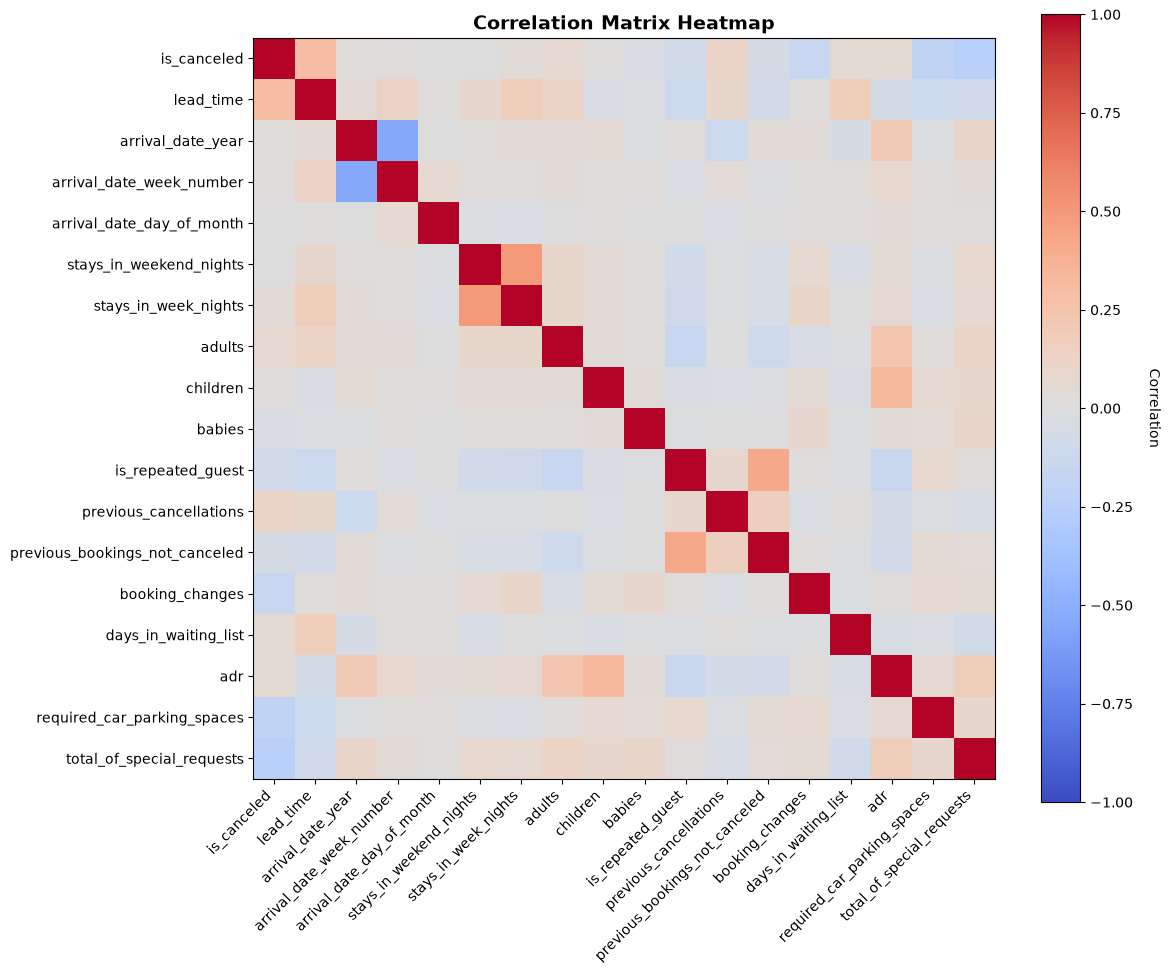

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = df_clean.select_dtypes('number').corr()

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation", rotation=270, labelpad=20)

column_names = corr_matrix.columns
ax.set_xticks(np.arange(len(column_names)))
ax.set_yticks(np.arange(len(column_names)))
ax.set_xticklabels(column_names, rotation=45, ha="right")
ax.set_yticklabels(column_names)

ax.set_title("Correlation Matrix Heatmap", fontsize=14, fontweight="bold")

fig.tight_layout()
plt.show()

# 4. Manipulating the Data

**Exercise 15.** **Sort** `df_clean` by `adr` in descending order and show the **top 10** most expensive bookings (columns `hotel`, `arrival_date_month`, `adr`).

In [114]:
sorted_value = df_clean.sort_values("adr" ,ascending=False)
top_10 = sorted_value.head(10)
result = top_10[["hotel" , "arrival_date_month" , "adr"]]
result

,hotel,arrival_date_month,adr
48515,City Hotel,March,5400.00
111403,City Hotel,May,510.00
15083,Resort Hotel,July,508.00
103912,City Hotel,December,451.50
13142,Resort Hotel,August,450.00
13391,Resort Hotel,August,437.00
39155,Resort Hotel,August,426.25
39568,Resort Hotel,August,402.00
39118,Resort Hotel,July,397.38
13323,Resort Hotel,August,392.00


**Exercise 16.** Use boolean filtering to select **City Hotel bookings that were cancelled** (`hotel == "City Hotel"` **and** `is_canceled == 1`). How many are there?

In [121]:
cancelled = df_clean[(df_clean["hotel"] == "City Hotel") & (df_clean["is_canceled"] == 1)]
len(cancelled)

33079

**Exercise 17.** Group by `hotel` and compute the **mean `adr`** and the **cancellation rate** (mean of `is_canceled`) for each hotel. Which hotel cancels more?

In [122]:
hotel_state = df_clean.groupby("hotel")[["adr" , "is_canceled"]].mean()
hotel_state

,adr,is_canceled
hotel,,
City Hotel,105.503191,0.417859
Resort Hotel,94.985585,0.277681


**Exercise 18.** Produce a **grouped summary**: group by **both** `hotel` and `customer_type`, and aggregate `adr` with **mean, median and count** in one call.

In [125]:
# Your code here
summary = df_clean.groupby(["hotel" , "customer_type"])[["adr"]].agg(["mean" , "median" , "count"])
summary

adr               
                                    mean  median  count
hotel        customer_type                             
City Hotel   Contract          94.218807   91.00   2296
             Group             92.556357   85.00    291
             Transient        110.234181  104.22  59272
             Transient-Party   91.012970   90.00  17304
Resort Hotel Contract          79.124966   72.42   1776
             Group             75.026890   61.50    283
             Transient        101.124058   80.10  30204
             Transient-Party   75.508562   66.00   7783

**Exercise 19.** Build a **`crosstab`** of `hotel` (rows) vs `is_canceled` (columns) to count bookings in each combination.

In [126]:
# Your code here
combination = pd.crosstab(df_clean["hotel"] , df_clean["is_canceled"])
combination

is_canceled,0,1
hotel,,
City Hotel,46084,33079
Resort Hotel,28926,11120


**Exercise 20.** Build a **`pivot_table`** with `hotel` as the index, `is_canceled` as the columns, and the **mean `adr`** as the values. Do cancelled bookings have a different average price?

In [157]:
# Your code here
pivot = pd.pivot_table(
    data=df_clean,
    index="hotel",           # Rows: hotel types
    columns="is_canceled",   # Columns: cancelled status (0 or 1)
    values="adr",            # Values: average price
    aggfunc="mean"           # How to combine: use mean (average)
)
pivot

is_canceled,0,1
hotel,,
City Hotel,106.036141,104.760710
Resort Hotel,90.825887,105.806037


# 5. Putting It Together

**Exercise 21.** Compute the **cancellation rate per arrival month** and plot it as a bar chart, with the months in **calendar order** (January → December), not alphabetical.

*Tip: group by `arrival_date_month`, take the mean of `is_canceled`, then `.reindex(...)` with a list of month names in order.*

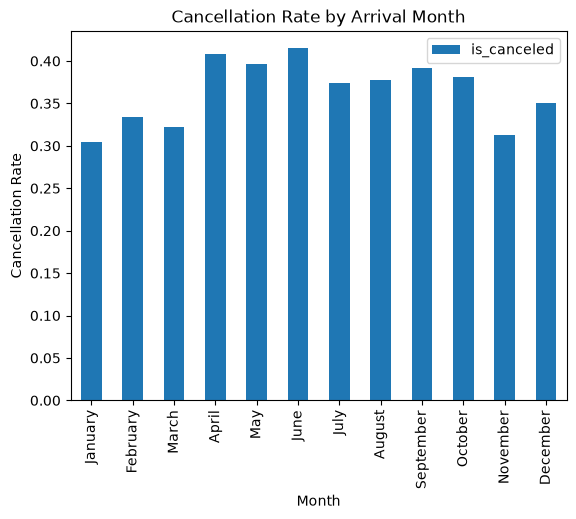

In [129]:
plotting = df_clean.groupby("arrival_date_month")[["is_canceled"]].mean()
month_order = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]
plotting = plotting.reindex(month_order)

plotting.plot(kind= "bar")
plt.title("Cancellation Rate by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate")
plt.show()

## 🏆 Challenge Exercises

These are open-ended — combine the skills above and explain what you find in a short comment.

1. **Total nights & revenue:** create `total_nights = stays_in_weekend_nights + stays_in_week_nights`, then estimate revenue as `adr * total_nights`. Which `market_segment` brings the most total estimated revenue? (Remember: cancelled bookings earn nothing — decide how to handle them and justify it.)
2. **Lead time vs cancellation:** bin `lead_time` into buckets (e.g. `pd.cut` at 0, 30, 90, 180, 365, ∞) and show the cancellation rate per bucket. Do bookings made far in advance get cancelled more?
3. **Repeat guests:** compare the cancellation rate of repeated guests (`is_repeated_guest == 1`) vs new guests. Visualize the difference.
4. **Your own question:** pose one question about the data, answer it with code + a plot, and write a one-line conclusion.

# Your own question

### "Which country books most?"

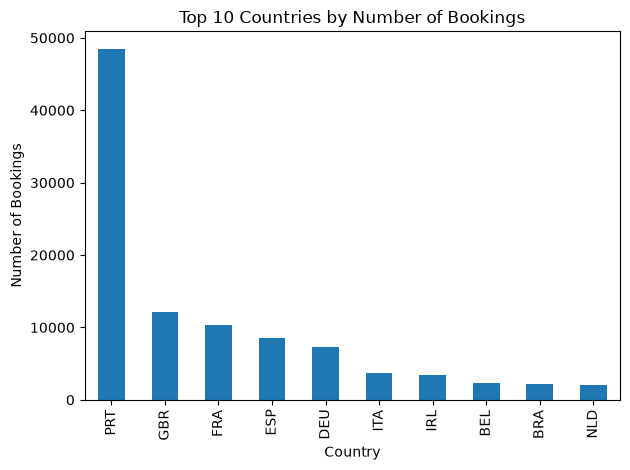

In [ ]:
booking_by_country = df_clean["country"].value_counts()
sort = booking_by_country.sort_values(ascending=False)
top_10_country = sort.head(10)
top_10_country.plot(kind = "bar")
plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()


# Portugal is the dominant market with  48483 bookings, 
# representing 40.67% of all bookings and significantly 
# outpacing other countries.


## Conclusion

In a short markdown note below, summarise **3 things you learned** about hotel bookings from this analysis (e.g. which hotel cancels more, when cancellations peak, what drives price).

*Write your conclusions here...*

# 1) Which hotel type receives more bookings, and by how much?

In [ ]:
df_clean["hotel"].value_counts()
### City hotel receives more booking from Resort hotel by 39117 booking

hotel
City Hotel      79163
Resort Hotel    40046
Name: count, dtype: int64

# 2) Which countries provide the most bookings to the hotel, and does one country dominate the market?

In [ ]:
print(top_10_country)
total = df_clean.shape[0]
portugal_count = top_10_country.iloc[0]
portugal_pct = (portugal_count / total) * 100

print(f"\nPortugal: {portugal_count} bookings ({portugal_pct:.1f}%)")
print(f"2nd: {top_10_country.index[1]} - {top_10_country.iloc[1]} bookings")
print(f"3rd: {top_10_country.index[2]} - {top_10_country.iloc[2]} bookings")

#Portugal is the dominant market with 40.7% of all bookings, 
#while Great Britain (2nd) and France (3rd) account for only 10% each, 
#showing heavy market concentration in Portugal.

country
PRT    48483
GBR    12119
FRA    10401
ESP     8560
DEU     7285
ITA     3761
IRL     3374
BEL     2342
BRA     2222
NLD     2103
Name: count, dtype: int64

Portugal: 48483 bookings (40.7%)
2nd: GBR - 12119 bookings
3rd: FRA - 10401 bookings


# 3)How widely does the nightly hotel rate (ADR) vary across bookings?

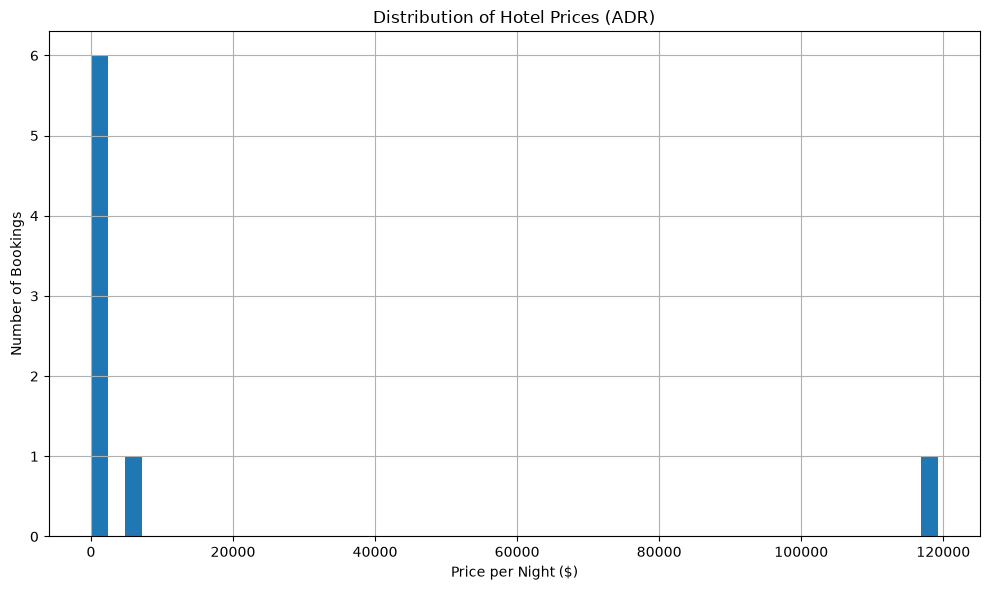

count    119209.000000
mean        101.970001
std          50.433242
min           0.000000
25%          69.500000
50%          94.950000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [155]:
hotel_rate = df_clean["adr"].describe()
plt.figure(figsize=(10, 6))
hotel_rate.hist(bins=50)
plt.title("Distribution of Hotel Prices (ADR)")
plt.xlabel("Price per Night ($)")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

hotel_rate